In [1]:
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

DB = '../data/humans_clean.sqlite3'

MANUAL_COUNTRY = {
    'P214': 'International', 'P2671': 'USA', 'P213': 'International',
    'P10832': 'USA', 'P13049': 'Germany', 'P13591': 'USA', 'P3368': 'USA',
    'P2600': 'USA', 'P2949': 'USA', 'P2163': 'USA', 'P1819': 'Netherlands',
    'P12098': 'Russia', 'P1871': 'Europe', 'P3537': 'Europe',
    'P2446': 'Germany', 'P1953': 'USA', 'P14105': 'International',
    'P1447': 'USA', 'P3430': 'USA', 'P12338': 'International',
    'P1368': 'Latvia', 'P245': 'USA', 'P1315': 'Australia',
    'P2639': 'Germany', 'P12458': 'International', 'P2003': 'USA',
    'P2013': 'USA', 'P1280': 'Ireland', 'P9065': 'Switzerland',
    'P3696': 'USA', 'P1249': 'Denmark', 'P7859': 'USA', 'P5034': 'USA',
    'P1015': 'Norway', 'P1017': 'Vatican City', 'P3527': 'Europe',
    'P2020': 'Europe', 'P2369': 'Europe', 'P1284': 'Hungary',
    'P409': 'Australia', 'P396': 'Italy', 'P3065': 'Europe',
    'P1005': 'Sweden', 'P906': 'Italy', 'P950': 'Spain',
    'P7293': 'Netherlands', 'P691': 'Czechia', 'P1415': 'UK',
    'P7699': 'Netherlands', 'P723': 'Netherlands', 'P4223': 'Germany',
}

WESTERN_COUNTRIES = {
    'USA', 'United States', 'Germany', 'France', 'Poland', 'Netherlands',
    'United Kingdom', 'UK', 'Italy', 'Spain', 'Sweden', 'Norway', 'Finland',
    'Denmark', 'Austria', 'Belgium', 'Switzerland', 'Portugal', 'Czechia',
    'Czech Republic', 'Slovakia', 'Greece', 'Hungary', 'Ireland', 'Canada',
    'Australia', 'New Zealand', 'Romania', 'Croatia', 'Serbia', 'Slovenia',
    'Lithuania', 'Latvia', 'Estonia', 'Bulgaria', 'Iceland', 'Luxembourg',
    'International', 'Europe', 'Vatican City', 'Kingdom of Italy',
    'Weimar Republic', 'German Reich',
}

COUNTRY_SHORT = {
    'United States': 'USA', 'United Kingdom': 'UK',
    "People's Republic of China": 'China', 'Republic of China': 'Taiwan',
    'Kingdom of Italy': 'Italy', 'internationality': 'Intl.',
    'International': 'Intl.', 'German Reich': 'Germany',
    'Weimar Republic': 'Germany', 'Vatican City': 'Vatican',
    'Kingdom of the Netherlands': 'Netherlands',
}

def make_label(name, country):
    if not country:
        return name
    cl = COUNTRY_SHORT.get(country, country)
    return f"{name} ({cl})"

In [2]:
# Load catalog metadata
conn = sqlite3.connect(DB)
cur = conn.execute('SELECT property_id, name_en, count, country_name FROM identifier_types ORDER BY count DESC')
all_catalogs = []
pid_to_info = {}
for pid, name, count, country in cur.fetchall():
    if name is None:
        continue
    co = country if country else MANUAL_COUNTRY.get(pid)
    all_catalogs.append((pid, name, count, co))
    pid_to_info[pid] = (name, co)

western = [(pid, n, c, co) for pid, n, c, co in all_catalogs if co and co in WESTERN_COUNTRIES][:20]
non_western = [(pid, n, c, co) for pid, n, c, co in all_catalogs if co and co not in WESTERN_COUNTRIES][:20]

# Before/after era split
conn.execute('PRAGMA cache_size=-2000000')
conn.execute('PRAGMA journal_mode=WAL')
print("Running heavy join (identifiers x impact_date)... this takes ~10 min")
cur = conn.execute("""
    SELECT i.property_id, i.identifier_name,
           SUM(CASE WHEN CAST(SUBSTR(d.impact_date, 1, CASE WHEN d.impact_date LIKE '-%' THEN 5 ELSE 4 END) AS INTEGER) < 1400 THEN 1 ELSE 0 END) as before_15,
           SUM(CASE WHEN CAST(SUBSTR(d.impact_date, 1, CASE WHEN d.impact_date LIKE '-%' THEN 5 ELSE 4 END) AS INTEGER) >= 1800 THEN 1 ELSE 0 END) as after_19
    FROM identifiers i
    INNER JOIN individuals_impact_date d ON i.wikidata_id = d.wikidata_id
    GROUP BY i.property_id, i.identifier_name
""")
rows = cur.fetchall()
conn.close()

before_data, after_data = [], []
for pid, name, bef, aft in rows:
    if name is None:
        continue
    co = pid_to_info.get(pid, (None, None))[1]
    if bef and bef > 0:
        before_data.append((pid, name, bef, co))
    if aft and aft > 0:
        after_data.append((pid, name, aft, co))

before_data.sort(key=lambda x: x[2], reverse=True)
after_data.sort(key=lambda x: x[2], reverse=True)
before_top20 = before_data[:20]
after_top20 = after_data[:20]

print(f'Before 15th c: {len(before_data)} catalogs, After 19th c: {len(after_data)} catalogs')
print(f'Western: {len(western)}, Non-Western: {len(non_western)}')

Running heavy join (identifiers x impact_date)... this takes ~10 min


Before 15th c: 493 catalogs, After 19th c: 2176 catalogs
Western: 20, Non-Western: 20


In [3]:
def draw_panel(ax, items, panel_label):
    items = list(reversed(items))
    labels = [make_label(n, co) for _, n, _, co in items]
    values = [c for _, _, c, _ in items]
    y = np.arange(len(items))

    ax.barh(y, values, height=0.72, color='#4a4a4a', edgecolor='white', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Number of individuals', fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'
    ))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', length=0)
    ax.text(0.97, 0.97, panel_label, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

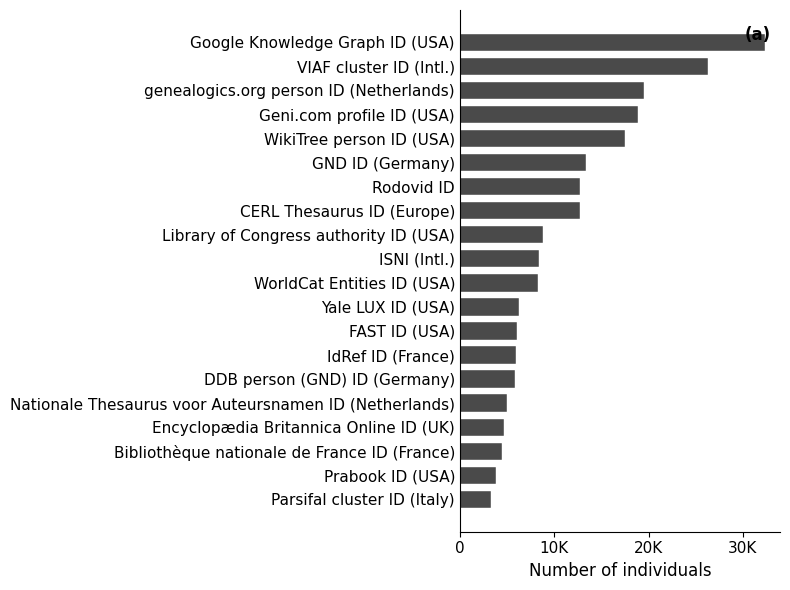

In [4]:
# (a) Before 15th century
fig, ax = plt.subplots(figsize=(8, 6))
draw_panel(ax, before_top20, '(a)')
plt.tight_layout()
plt.show()

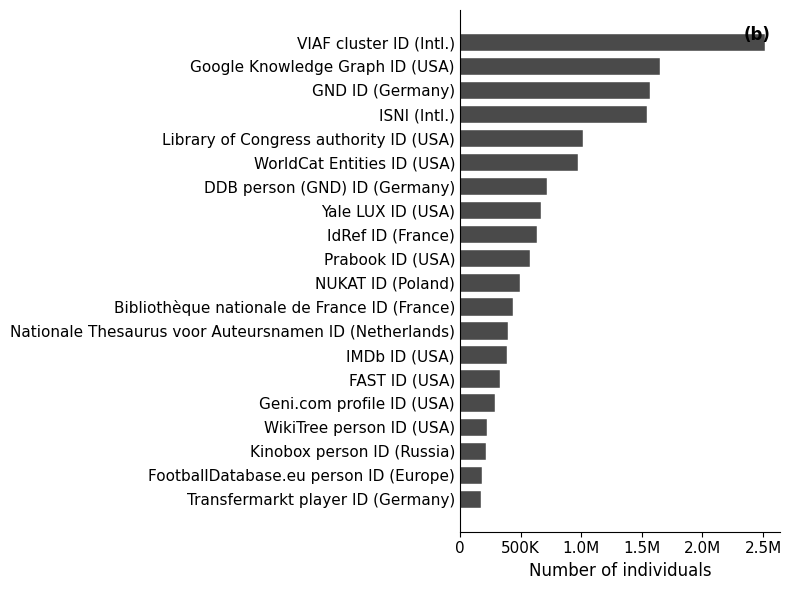

In [5]:
# (b) After 19th century
fig, ax = plt.subplots(figsize=(8, 6))
draw_panel(ax, after_top20, '(b)')
plt.tight_layout()
plt.show()

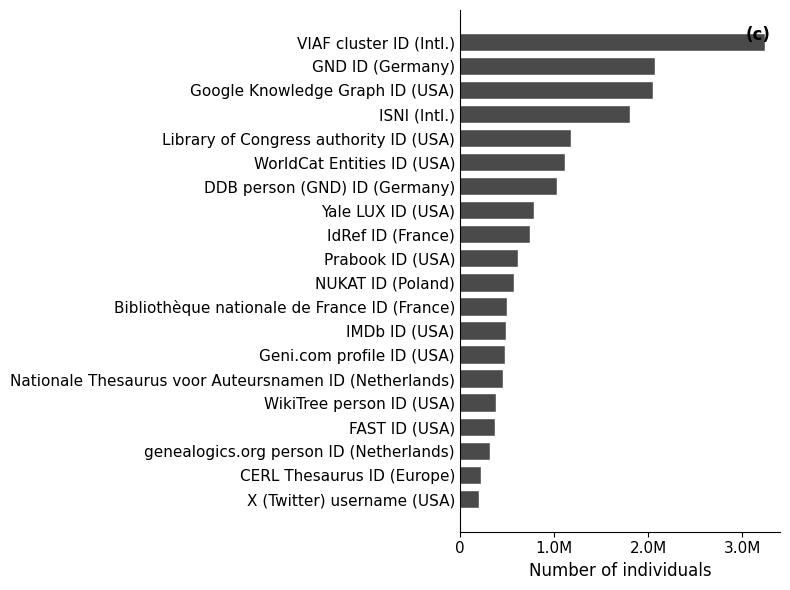

In [6]:
# (c) Western catalogs
fig, ax = plt.subplots(figsize=(8, 6))
draw_panel(ax, western, '(c)')
plt.tight_layout()
plt.show()

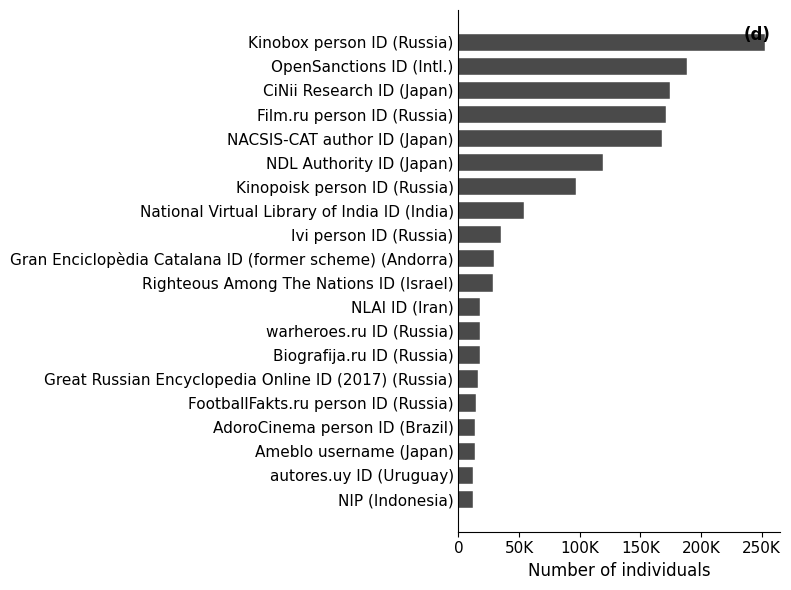

In [7]:
# (d) Non-Western catalogs
fig, ax = plt.subplots(figsize=(8, 6))
draw_panel(ax, non_western, '(d)')
plt.tight_layout()
plt.show()

In [8]:
# --- Top 10 catalogs: Tang Dynasty vs Roman Empire ---
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

polity_catalogs = {}
for label, where in [('Tang Dynasty', "ic.polity_name LIKE 'Tang Dynasty%'"),
                      ('Roman Empire', "ic.polity_name LIKE 'Roman Empire%' AND ic.polity_name NOT LIKE '%Holy%'")]:
    cur = conn.execute(f'''
        SELECT it.property_id, it.name_en, it.country_name,
               COUNT(DISTINCT ic.wikidata_id) AS n
        FROM individuals_cliopatria ic
        JOIN identifiers i ON ic.wikidata_id = i.wikidata_id
        JOIN identifier_types it ON i.property_id = it.property_id
        WHERE {where}
        GROUP BY it.property_id
        ORDER BY n DESC
        LIMIT 10
    ''')
    rows = [(pid, name, cnt, co) for pid, name, co, cnt in cur.fetchall()]
    polity_catalogs[label] = rows
    print(f"\n{label} — top 10 catalogs:")
    for pid, name, cnt, co in rows:
        print(f"  {make_label(name, co)}: {cnt:,}")

conn.close()


Tang Dynasty — top 10 catalogs:
  Geni.com profile ID: 6,530
  Google Knowledge Graph ID: 1,257
  Yale LUX ID: 644
  VIAF cluster ID: 256
  Library of Congress authority ID (USA): 185
  WorldCat Entities ID: 135
  ISNI: 118
  Dharma Drum Institute of Liberal Arts person ID (Taiwan): 107
  Nationale Thesaurus voor Auteursnamen ID (Netherlands): 102
  FAST ID: 98



Roman Empire — top 10 catalogs:
  VIAF cluster ID: 1,136
  Google Knowledge Graph ID: 1,064
  GND ID (Germany): 972
  CERL Thesaurus ID: 751
  Library of Congress authority ID (USA): 660
  DDB person (GND) ID: 598
  ISNI: 595
  WorldCat Entities ID: 551
  FAST ID: 537
  Yale LUX ID: 508


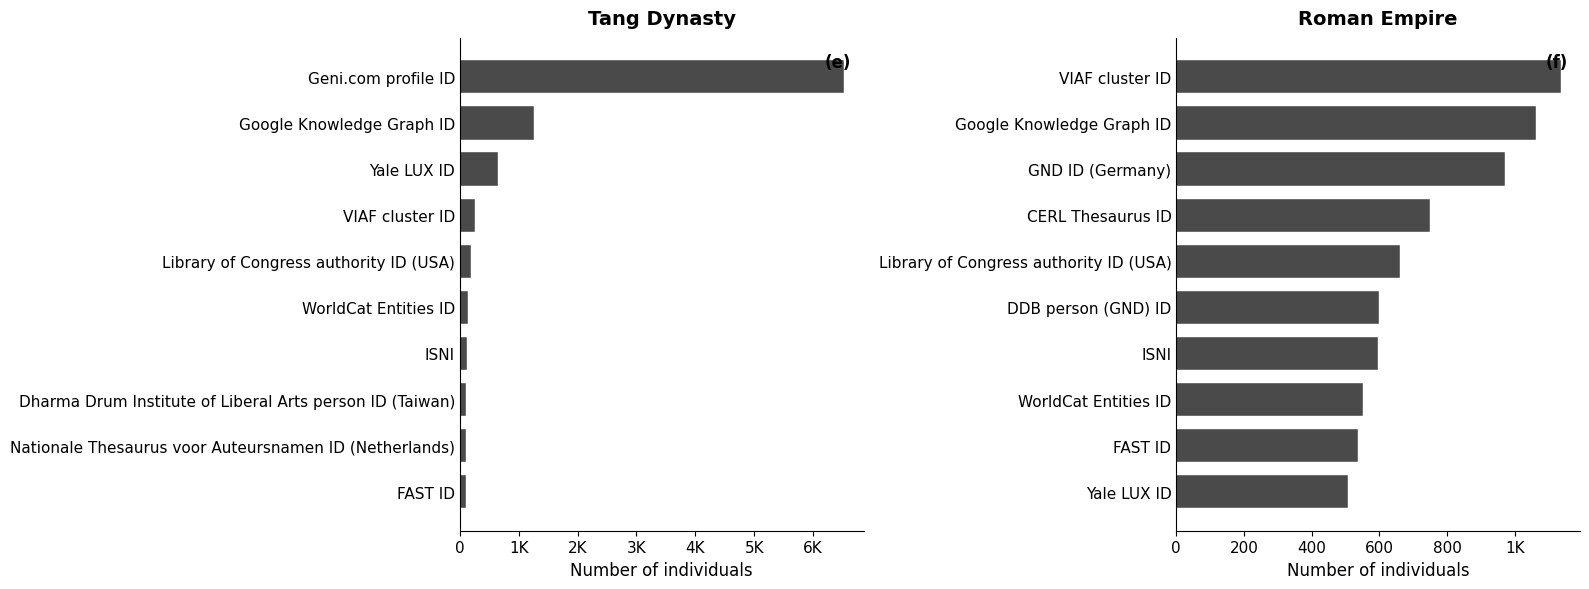

In [9]:
# (e) Tang Dynasty vs Roman Empire — side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, panel in [(ax1, 'Tang Dynasty', '(e)'), (ax2, 'Roman Empire', '(f)')]:
    items = list(reversed(polity_catalogs[label]))
    labels = [make_label(n, co) for _, n, _, co in items]
    values = [c for _, _, c, _ in items]
    y = np.arange(len(items))

    ax.barh(y, values, height=0.72, color='#4a4a4a', edgecolor='white', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Number of individuals', fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'
    ))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', length=0)

    ax.set_title(label, fontsize=14, fontweight='bold', color='black', pad=10)
    ax.text(0.97, 0.97, panel, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()